In [1]:
import os, requests, zipfile
from google.colab import userdata

token = userdata.get('KAGGLE_TOKEN')
headers = {"Authorization": f"Bearer {token}"}

print("Downloading...")
r = requests.get(
    "https://www.kaggle.com/api/v1/datasets/download/abhisheksjha/time-series-air-quality-data-of-india-2010-2023",
    headers=headers,
    stream=True
)

with open('/content/air_quality.zip', 'wb') as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

os.makedirs('/content/air_quality', exist_ok=True)
with zipfile.ZipFile('/content/air_quality.zip', 'r') as z:
    z.extractall('/content/air_quality')

print("Done!")

Downloading...
Done!


In [2]:
import pandas as pd
import numpy as np

In [3]:
final_files = {
    'Delhi':     'DL030',
    'Mumbai':    'MH015',
    'Chennai':   'TN003',
    'Hyderabad': 'TG004',
    'Bengaluru': 'KA008',
}

kaggle_dfs = {}

for city, fname in final_files.items():
    df = pd.read_csv(f'/content/air_quality/{fname}.csv')
    pm25_col = [c for c in df.columns if 'PM2.5' in c][0]
    df = df[['From Date', pm25_col]].copy()
    df.columns = ['date', 'pm25']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).set_index('date')
    daily = df['pm25'].resample('D').mean().reset_index()
    daily.columns = ['date', 'pm25']
    daily = daily[daily['date'] >= '2019-01-01'].reset_index(drop=True)
    daily['pm25'] = daily['pm25'].interpolate(method='linear')
    kaggle_dfs[city] = daily

for city, df in kaggle_dfs.items():
    print(f"{city}: {len(df)} days | nulls: {df['pm25'].isna().sum()}")

Delhi: 1551 days | nulls: 0
Mumbai: 1381 days | nulls: 0
Chennai: 1551 days | nulls: 0
Hyderabad: 1551 days | nulls: 0
Bengaluru: 1551 days | nulls: 0


In [4]:
def walk_forward_splits(df, min_train_days = 365, forecast_horizon = 30, step_size = 30):
  splits = []
  n = len(df)
  start = min_train_days

  while start + step_size <= n:
    train = df.iloc[:start].copy()
    test = df.iloc[start : start + forecast_horizon].copy()
    splits.append((train,test))
    start += step_size
  return splits

In [5]:
!git clone https://github.com/shaheeeeeeeeem/air-quality-forecasting.git

Cloning into 'air-quality-forecasting'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 40 (delta 10), reused 38 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 2.50 MiB | 17.19 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [6]:
import pandas as pd
import os

repo_path = '/content/air-quality-forecasting/data/processed'

cities = ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bengaluru']

kaggle_dfs = {}

for city in cities:
    filepath = os.path.join(repo_path, f'{city}_features.csv')
    df = pd.read_csv(filepath, parse_dates=['date'])
    kaggle_dfs[city] = df

for city, df in kaggle_dfs.items():
    print(f"{city}: {df.shape[0]} rows, {df.shape[1]} columns")

Delhi: 1551 rows, 33 columns
Mumbai: 1381 rows, 33 columns
Chennai: 1551 rows, 33 columns
Hyderabad: 1551 rows, 33 columns
Bengaluru: 1551 rows, 33 columns


In [7]:
target_col = 'pm25_log'

exclude_cols = ['date', 'pm25', 'pm25_log']

feature_cols = [c for c in kaggle_dfs['Delhi'].columns if c not in exclude_cols]

print(feature_cols)

['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30', 'roll_min_7', 'roll_max_7', 'roll_min_30', 'roll_max_30', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'is_diwali', 'is_republic_day', 'is_holi', 'is_new_year', 'is_outlier']


In [8]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = []

for city, df in kaggle_dfs.items():
  splits = walk_forward_splits(df)

  for train, test in splits:
    X_train, y_train = train[feature_cols], train[target_col]
    X_test, y_test = test[feature_cols], test[target_col]

    model = lgb.LGBMRegressor(
        n_estimators = 100,
        learning_rate = 0.05,
        num_leaves = 31,
        random_state = 42,
        verbose = 1
    )

    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)

    y_test_actual = np.expm1(y_test)
    preds_actual = np.expm1(pred_log)

    mae = mean_absolute_error(y_test_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    results.append({'city': city, 'fold_end': test['date'].iloc[-1], 'mae': mae, 'rmse': rmse})


results_df = pd.DataFrame(results)
results_df.head()

Streaming output truncated to the last 5000 lines.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4776
[LightGBM] [Info] Number of data points in the train set: 1175, number of used features: 25
[LightGBM] [Info] Start training from score 3.423800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4782
[LightGBM] [Info] Number of data points in the train set: 1205, number of used features: 25
[LightGBM] [Info] Start training from score 3.410409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` t

,city,fold_end,mae,rmse
0,Delhi,2020-01-30,52.541209,66.043755
1,Delhi,2020-02-29,33.047649,40.616128
2,Delhi,2020-03-30,20.604949,25.772350
3,Delhi,2020-04-29,17.680261,22.231661
4,Delhi,2020-05-29,11.580203,15.480304


In [9]:
results_df.groupby('city')[['mae', 'rmse']].mean()

,mae,rmse
city,,
Bengaluru,7.452464,11.373443
Chennai,6.595849,9.332375
Delhi,25.735055,34.269574
Hyderabad,7.286990,8.991442
Mumbai,10.134551,13.142100


In [10]:
import matplotlib.pyplot as plt

model.booster_.feature_name()
importances = model.booster_.feature_importance(importance_type='gain')
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
feat_imp.head(10)

,0
lag_1,3857.228020
doy_cos,125.580692
roll_mean_7,92.101391
lag_2,91.951093
roll_mean_30,85.207371
lag_365,84.579289
roll_mean_14,80.667450
roll_std_30,66.610837
lag_14,56.455482
lag_3,47.548962


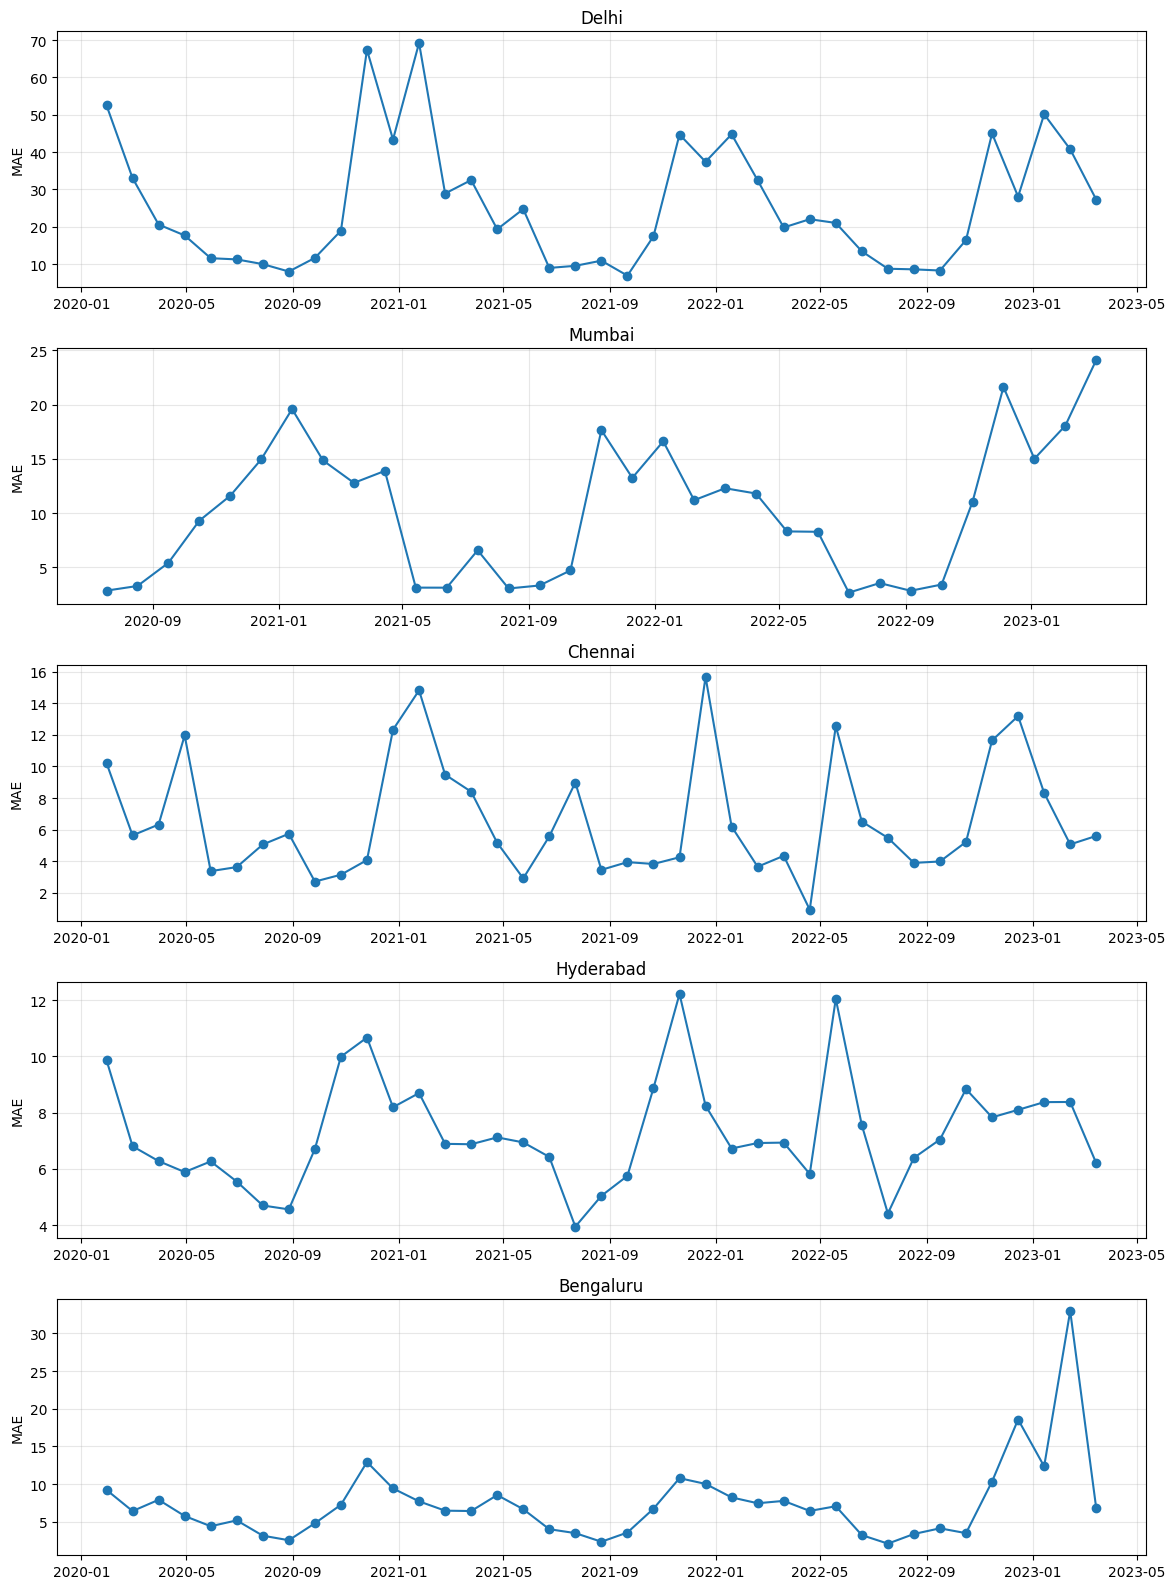

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=False)

for ax, city in zip(axes, results_df['city'].unique()):
    city_data = results_df[results_df['city'] == city].sort_values('fold_end')
    ax.plot(city_data['fold_end'], city_data['mae'], marker='o')
    ax.set_title(city)
    ax.set_ylabel('MAE')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
bengaluru_worst = results_df[results_df['city'] == 'Bengaluru'].sort_values('mae', ascending=False).head(3)
bengaluru_worst

,city,fold_end,mae,rmse
187,Bengaluru,2023-02-13,32.957428,103.328406
185,Bengaluru,2022-12-15,18.571190,30.885683
160,Bengaluru,2020-11-25,12.934439,16.596562
